# P17A Ablation Analysis (KuaiRecLargeStrictPosV2_0.2)

This notebook analyzes completed results from `run_ablation_12` and visualizes NDCG@20 and HR@20 by ablation topic.

Metric rule used here: **test performance selected from the best-validation trial**.

In [5]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

ROOT = Path('/workspace/FeaturedMoE')
SUMMARY_PATH = ROOT / 'experiments/run/artifacts/logs/fmoe_n3/ablation_feature_add_v3_a12_kuairec_v1/KuaiRecLargeStrictPosV2_0.2/summary.csv'
OUT_DIR = ROOT / 'experiments/run/fmoe_n3/ablation/docs_results'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH

PosixPath('/workspace/FeaturedMoE/experiments/run/artifacts/logs/fmoe_n3/ablation_feature_add_v3_a12_kuairec_v1/KuaiRecLargeStrictPosV2_0.2/summary.csv')

## Load Summary and Extract Metrics

The extractor is robust to different key spellings (for example `ndcg@20`, `ndcg_20`, `hit@20`, `hr20`).

In [6]:
summary_raw = pd.read_csv(SUMMARY_PATH)
summary = summary_raw.copy()

status_col = next((c for c in ['run_status', 'status', 'state'] if c in summary.columns), None)
if status_col is not None:
    completed_labels = {'run_complete', 'completed', 'complete', 'done', 'success', 'succeeded'}
    status_norm = summary[status_col].astype(str).str.strip().str.lower()
    summary = summary[status_norm.isin(completed_labels)].copy()

result_path_col = next((c for c in ['result_path', 'best_result_path', 'run_result_path'] if c in summary.columns), None)
if result_path_col is None:
    raise KeyError(f'No result path column found. Available columns: {list(summary.columns)}')

# If no completed rows exist yet, fall back to rows that at least have result paths.
if summary.empty:
    summary = summary_raw.copy()
    if result_path_col in summary.columns:
        has_path = summary[result_path_col].notna() & summary[result_path_col].astype(str).str.strip().ne('')
        summary = summary[has_path].copy()

def _norm_key(s: str) -> str:
    return re.sub(r'[^a-z0-9]', '', str(s).lower())

def _to_float(x):
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    if isinstance(x, str):
        try:
            return float(x)
        except ValueError:
            return None
    return None

def _find_metric(obj, alias_norms):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if _norm_key(k) in alias_norms:
                fv = _to_float(v)
                if fv is not None:
                    return fv
        for v in obj.values():
            found = _find_metric(v, alias_norms)
            if found is not None:
                return found
    elif isinstance(obj, list):
        for v in obj:
            found = _find_metric(v, alias_norms)
            if found is not None:
                return found
    return None

NDCG20_ALIASES = {_norm_key(x) for x in ['ndcg20', 'ndcg@20', 'ndcg_20']}
HR20_ALIASES = {_norm_key(x) for x in ['hr20', 'hr@20', 'hit20', 'hit@20', 'hitrate20', 'hitratio20']}

def load_result_metrics(result_path_str):
    p = Path(str(result_path_str))
    if not p.exists():
        return {'test_ndcg20': None, 'test_hr20': None, 'valid_ndcg20': None, 'valid_hr20': None}

    with p.open('r', encoding='utf-8') as f:
        data = json.load(f)

    test_blob = data.get('test_result') or data.get('test_metrics') or data.get('test') or {}
    valid_blob = data.get('best_valid_result') or data.get('valid_result') or data.get('best_valid') or {}

    test_ndcg20 = _find_metric(test_blob, NDCG20_ALIASES)
    test_hr20 = _find_metric(test_blob, HR20_ALIASES)
    valid_ndcg20 = _find_metric(valid_blob, NDCG20_ALIASES)
    valid_hr20 = _find_metric(valid_blob, HR20_ALIASES)

    if test_ndcg20 is None:
        test_ndcg20 = _find_metric(data, NDCG20_ALIASES)
    if test_hr20 is None:
        test_hr20 = _find_metric(data, HR20_ALIASES)

    return {
        'test_ndcg20': test_ndcg20,
        'test_hr20': test_hr20,
        'valid_ndcg20': valid_ndcg20,
        'valid_hr20': valid_hr20,
    }

rows = []
for _, r in summary.iterrows():
    metrics = load_result_metrics(r.get(result_path_col, ''))
    rows.append({
        'setting_id': r.get('setting_id'),
        'setting_key': r.get('setting_key'),
        'setting_group': r.get('setting_group'),
        'setting_detail': r.get('setting_detail'),
        'seed': r.get('seed'),
        'test_ndcg20': metrics['test_ndcg20'],
        'test_hr20': metrics['test_hr20'],
        'valid_ndcg20': metrics['valid_ndcg20'],
        'valid_hr20': metrics['valid_hr20'],
        'run_best_valid_mrr20': r.get('run_best_valid_mrr20'),
        'test_mrr20': r.get('test_mrr20'),
    })

metrics_df = pd.DataFrame(rows)
metrics_df['setting_id_num'] = metrics_df['setting_id'].astype(str).str.extract(r'(\d+)').astype(float)
metrics_df = metrics_df.sort_values(['setting_id_num', 'setting_id']).reset_index(drop=True)

topic_order = ['baseline', 'layout', 'feature_drop', 'no_moe_bias', 'rule_router']
metrics_df['setting_group'] = pd.Categorical(metrics_df['setting_group'], categories=topic_order, ordered=True)

display_cols = [
    'setting_id', 'setting_group', 'setting_key', 'test_ndcg20', 'test_hr20',
    'valid_ndcg20', 'valid_hr20', 'run_best_valid_mrr20', 'test_mrr20'
 ]
metrics_df[display_cols]

,setting_id,setting_group,setting_key,test_ndcg20,test_hr20,valid_ndcg20,valid_hr20,run_best_valid_mrr20,test_mrr20
0,1,baseline,ABL-01_BASELINE_A12,0.1723,0.1825,0.1758,0.1897,0.1721,0.1695
1,2,layout,ABL-02_LAYOUT_NO_MACRO,0.1739,0.1879,0.1744,0.1873,0.1709,0.1701
2,3,layout,ABL-03_LAYOUT_NO_MID,0.1727,0.1825,0.1759,0.1889,0.1724,0.1700
3,4,layout,ABL-04_LAYOUT_NO_MICRO,0.1726,0.1844,0.1738,0.1862,0.1704,0.1695
4,5,layout,ABL-05_LAYOUT_ATTN_BEFORE_MID,0.1715,0.1817,0.1729,0.1840,0.1699,0.1687
5,6,feature_drop,ABL-06_FEATURE_DROP_CATEGORY,0.1727,0.1858,0.1733,0.1829,0.1707,0.1692
6,7,feature_drop,ABL-07_FEATURE_DROP_TIMESTAMP_DERIVED,0.1717,0.1814,0.1739,0.1840,0.1712,0.1691
7,8,feature_drop,ABL-08_FEATURE_DROP_CATEGORY_TIMESTAMP,0.1729,0.1860,0.1740,0.1845,0.1711,0.1694
8,9,no_moe_bias,ABL-09_DENSE_GATED_BIAS_MACRO_MID,0.1685,0.1746,0.1694,0.1750,0.1678,0.1668
9,10,no_moe_bias,ABL-10_DENSE_GATED_BIAS_FULL,0.1669,0.1776,0.1666,0.1766,0.1638,0.1640


## Clean 2x2 Topic Subplots

The figure below excludes the standalone baseline-only panel.
Each topic subplot includes the final baseline model as the leftmost reference bar.

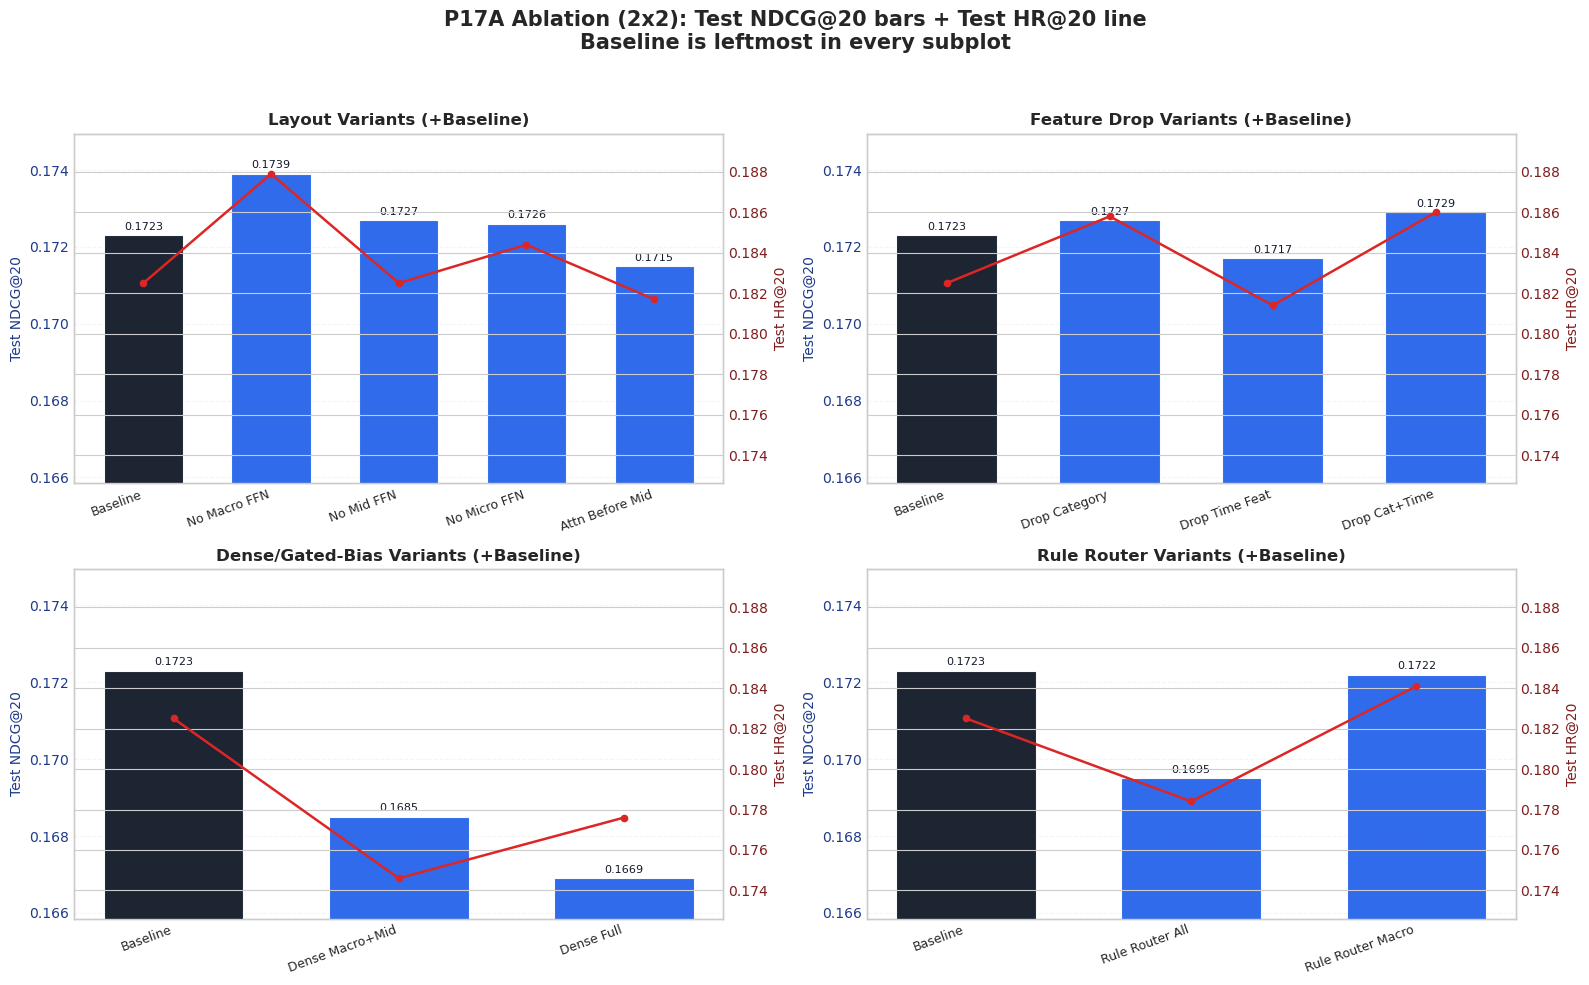

In [9]:
# Keep one representative row per setting (best-valid criterion).
rank_col = 'run_best_valid_mrr20' if 'run_best_valid_mrr20' in metrics_df.columns else 'test_mrr20'
plot_base = metrics_df.copy()
plot_base[rank_col] = pd.to_numeric(plot_base[rank_col], errors='coerce')
plot_base = (
    plot_base
    .sort_values(rank_col, ascending=False, na_position='last')
    .groupby('setting_key', as_index=False)
    .head(1)
    .copy()
)

# Friendly short labels for x-axis (instead of numeric setting id).
label_map = {
    'ABL-01_BASELINE_A12': 'Baseline',
    'ABL-02_LAYOUT_NO_MACRO': 'No Macro FFN',
    'ABL-03_LAYOUT_NO_MID': 'No Mid FFN',
    'ABL-04_LAYOUT_NO_MICRO': 'No Micro FFN',
    'ABL-05_LAYOUT_ATTN_BEFORE_MID': 'Attn Before Mid',
    'ABL-06_FEATURE_DROP_CATEGORY': 'Drop Category',
    'ABL-07_FEATURE_DROP_TIMESTAMP_DERIVED': 'Drop Time Feat',
    'ABL-08_FEATURE_DROP_CATEGORY_TIMESTAMP': 'Drop Cat+Time',
    'ABL-09_DENSE_GATED_BIAS_MACRO_MID': 'Dense Macro+Mid',
    'ABL-10_DENSE_GATED_BIAS_FULL': 'Dense Full',
    'ABL-11_RULE_ROUTER_ALL': 'Rule Router All',
    'ABL-12_RULE_ROUTER_MACRO_ONLY': 'Rule Router Macro',
}

def _short_label(setting_key: str) -> str:
    key = str(setting_key)
    if key in label_map:
        return label_map[key]
    # Fallback: remove ABL prefix and compact underscores.
    key = re.sub(r'^ABL-\d+_', '', key)
    return key.replace('_', ' ').title()

plot_base['short_label'] = plot_base['setting_key'].map(_short_label)

# Build 4 topics only (exclude baseline-only panel).
topics_4 = ['layout', 'feature_drop', 'no_moe_bias', 'rule_router']
baseline_row = plot_base[plot_base['setting_group'].eq('baseline')].copy()
if baseline_row.empty:
    raise ValueError('Baseline row not found. Cannot prepend baseline to each subplot.')
baseline_row = baseline_row.sort_values(rank_col, ascending=False).head(1).copy()

plot_panels = {}
for tp in topics_4:
    d = plot_base[plot_base['setting_group'].eq(tp)].copy()
    d = d.sort_values(['setting_id_num', 'setting_id'])
    # Prepend baseline as leftmost reference.
    d = pd.concat([baseline_row, d], ignore_index=True)
    # Remove duplicate baseline if any topic accidentally contains it.
    d = d.drop_duplicates(subset=['setting_key'], keep='first').copy()
    plot_panels[tp] = d

# Global y-limits to make cross-panel visual comparison easier.
all_ndcg = pd.concat([plot_panels[t]['test_ndcg20'] for t in topics_4], axis=0).astype(float)
all_hr = pd.concat([plot_panels[t]['test_hr20'] for t in topics_4], axis=0).astype(float)

def _ylim_with_margin(s, low_clip=0.0, margin_ratio=0.12):
    s = pd.to_numeric(s, errors='coerce').dropna()
    if s.empty:
        return (0.0, 1.0)
    mn, mx = float(s.min()), float(s.max())
    if np.isclose(mn, mx):
        pad = max(0.005, abs(mx) * 0.05)
    else:
        pad = (mx - mn) * margin_ratio
    lo = max(low_clip, mn - pad)
    hi = min(1.0, mx + pad)
    if np.isclose(lo, hi):
        hi = min(1.0, lo + 0.01)
    return lo, hi

ndcg_ylim = _ylim_with_margin(all_ndcg, low_clip=0.0, margin_ratio=0.15)
hr_ylim = _ylim_with_margin(all_hr, low_clip=0.0, margin_ratio=0.15)

# Clean theme configuration.
bar_color = '#2563EB'
line_color = '#DC2626'
baseline_color = '#111827'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

panel_title_map = {
    'layout': 'Layout Variants (+Baseline)',
    'feature_drop': 'Feature Drop Variants (+Baseline)',
    'no_moe_bias': 'Dense/Gated-Bias Variants (+Baseline)',
    'rule_router': 'Rule Router Variants (+Baseline)',
}

for i, tp in enumerate(topics_4):
    ax1 = axes[i]
    d = plot_panels[tp].copy().reset_index(drop=True)
    x = np.arange(len(d))

    # Baseline bar emphasized with a separate color.
    colors = [baseline_color if j == 0 else bar_color for j in range(len(d))]
    bars = ax1.bar(
        x, d['test_ndcg20'].astype(float), width=0.62, color=colors, alpha=0.95,
        edgecolor='white', linewidth=0.8, zorder=3
    )

    # Keep horizontal grid subtle and behind bars.
    ax1.set_axisbelow(True)
    ax1.yaxis.grid(True, linestyle='--', alpha=0.18, zorder=0)
    ax1.xaxis.grid(False)

    ax1.set_ylim(*ndcg_ylim)
    ax1.set_ylabel('Test NDCG@20', color='#1E3A8A')
    ax1.tick_params(axis='y', labelcolor='#1E3A8A')

    # Small value labels on top of bars.
    y_span = ndcg_ylim[1] - ndcg_ylim[0]
    for rect, val in zip(bars, d['test_ndcg20'].astype(float)):
        if pd.notna(val):
            ax1.text(
                rect.get_x() + rect.get_width() / 2,
                val + y_span * 0.01,
                f'{val:.4f}',
                ha='center',
                va='bottom',
                fontsize=8,
                color='#0F172A',
                zorder=5,
            )

    ax2 = ax1.twinx()
    ax2.plot(
        x, d['test_hr20'].astype(float), color=line_color, marker='o',
        linewidth=1.8, markersize=4.5, zorder=4
    )
    ax2.set_ylim(*hr_ylim)
    ax2.set_ylabel('Test HR@20', color='#7F1D1D')
    ax2.tick_params(axis='y', labelcolor='#7F1D1D')

    # Short experiment names on x-axis.
    ax1.set_xticks(x)
    ax1.set_xticklabels(d['short_label'], rotation=20, ha='right', fontsize=9)
    ax1.set_title(panel_title_map.get(tp, tp), fontsize=12, fontweight='bold')

fig.suptitle(
    'P17A Ablation (2x2): Test NDCG@20 bars + Test HR@20 line\nBaseline is leftmost in every subplot',
    fontsize=15,
    fontweight='bold',
    y=0.98,
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Final Figure Export

Save the cleaned 2x2 figure and return the output path.

In [10]:
combined_path = OUT_DIR / 'p17a_topics_2x2_clean_ndcg20_hr20.png'
fig.savefig(combined_path, dpi=260, bbox_inches='tight')
combined_path

PosixPath('/workspace/FeaturedMoE/experiments/run/fmoe_n3/ablation/docs_results/p17a_topics_2x2_clean_ndcg20_hr20.png')